In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

1. **Load & preprocess**

In [2]:
df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df.drop('customerID', axis=1, inplace=True)

binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
mapping = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in binary_cols:
    df[col] = df[col].map(mapping)

multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
              'Contract','PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

features = [c for c in df.columns if c != 'Churn']
X = df[features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

scale_pos = (y_train==0).sum() / (y_train==1).sum()
print('Preprocessing done. Training all 3 models...')

Preprocessing done. Training all 3 models...


2. **Train all 3**

In [3]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos, eval_metric='logloss',
        random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'fpr': fpr, 'tpr': tpr,
        'accuracy':  round(accuracy_score(y_test, y_pred)*100, 1),
        'precision': round(precision_score(y_test, y_pred)*100, 1),
        'recall':    round(recall_score(y_test, y_pred)*100, 1),
        'f1':        round(f1_score(y_test, y_pred)*100, 1),
        'auc':       round(roc_auc_score(y_test, y_proba), 4)
    }
    print(f'{name:25s} | Acc {results[name]["accuracy"]}% | AUC {results[name]["auc"]}')

print('\nAll models trained!')

Logistic Regression       | Acc 74.0% | AUC 0.8414
Random Forest             | Acc 76.9% | AUC 0.8424
XGBoost                   | Acc 76.1% | AUC 0.8352

All models trained!


3. **Metrics comparison table**

In [4]:
metrics_df = pd.DataFrame([
    {'Model': name, 'Accuracy': r['accuracy'],
     'Precision': r['precision'], 'Recall': r['recall'],
     'F1': r['f1'], 'AUC-ROC': r['auc']}
    for name, r in results.items()
]).set_index('Model')

print('\n=== MODEL COMPARISON ===')
print(metrics_df.to_string())

best_model_name = metrics_df['AUC-ROC'].idxmax()
print(f'\nBest model by AUC-ROC: {best_model_name} ({metrics_df.loc[best_model_name, "AUC-ROC"]})')


=== MODEL COMPARISON ===
                     Accuracy  Precision  Recall    F1  AUC-ROC
Model                                                          
Logistic Regression      74.0       50.7    78.6  61.6   0.8414
Random Forest            76.9       54.9    74.1  63.0   0.8424
XGBoost                  76.1       53.6    74.1  62.2   0.8352

Best model by AUC-ROC: Random Forest (0.8424)


4.  **Visual comparison**

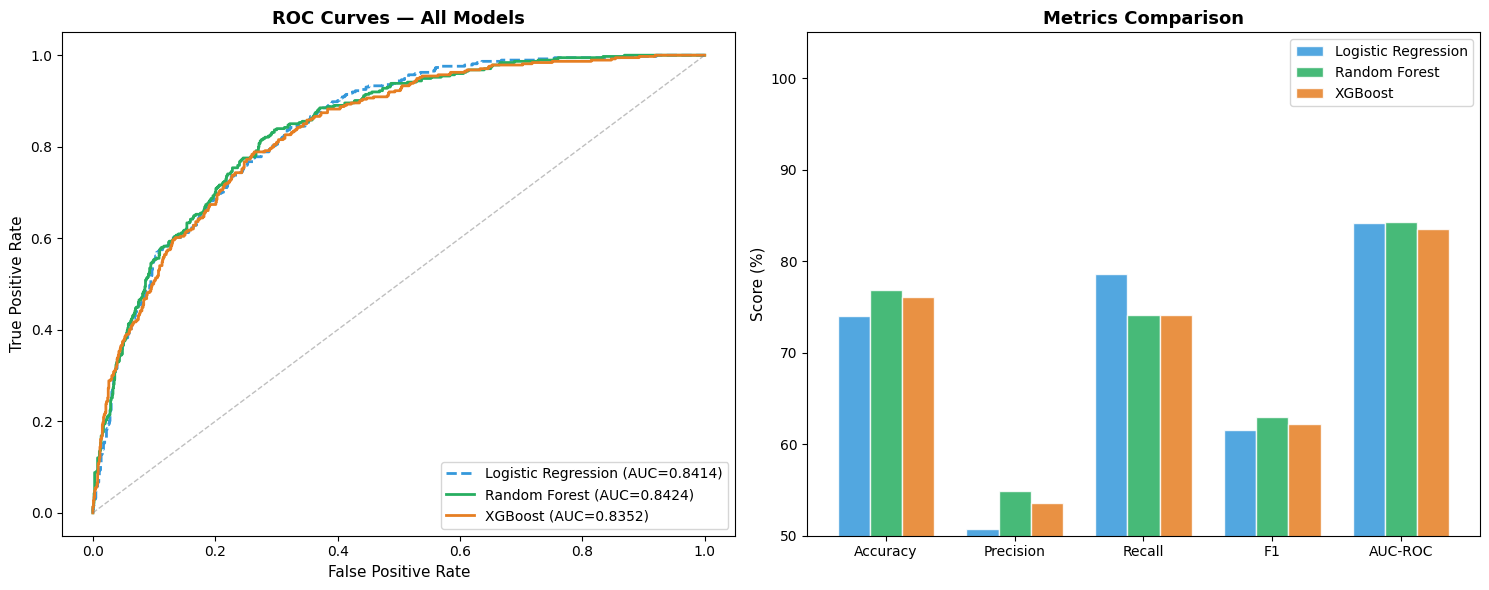

Saved: model_comparison.png


In [5]:
colors = {'Logistic Regression': '#3498db', 'Random Forest': '#27ae60', 'XGBoost': '#e67e22'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. ROC curves
for name, r in results.items():
    ls = '--' if name == 'Logistic Regression' else '-'
    axes[0].plot(r['fpr'], r['tpr'], lw=2, color=colors[name],
                 linestyle=ls, label=f"{name} (AUC={r['auc']})")
axes[0].plot([0,1],[0,1],'--', color='gray', lw=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# 2. Metric bars
metric_names = ['Accuracy','Precision','Recall','F1','AUC-ROC']
x = np.arange(len(metric_names))
width = 0.25
model_names = list(results.keys())

for i, (name, r) in enumerate(results.items()):
    vals = [r['accuracy'], r['precision'], r['recall'], r['f1'], r['auc']*100]
    bars = axes[1].bar(x + i*width, vals, width, label=name,
                       color=colors[name], alpha=0.85, edgecolor='white')

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metric_names)
axes[1].set_ylabel('Score (%)', fontsize=11)
axes[1].set_title('Metrics Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylim(50, 105)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

5. **Final Predictions Using Best Model**

In [7]:
best_model = results[best_model_name]['model']
X_all = scaler.transform(X) if best_model_name == 'Logistic Regression' else X

df_orig = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_orig['churn_probability'] = best_model.predict_proba(X_all)[:, 1]
df_orig['risk_segment'] = pd.cut(
    df_orig['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

print(f'Final predictions using: {best_model_name}\n')
print('Risk segment distribution:')
print(df_orig['risk_segment'].value_counts())

final = df_orig.sort_values('churn_probability', ascending=False)
print('\nTop 20 at-risk customers:')
print(final[['customerID','tenure','MonthlyCharges','Contract',
             'churn_probability','risk_segment']].head(20).to_string(index=False))

final.to_csv('final_churn_predictions.csv', index=False)
print('\nSaved: final_churn_predictions.csv')

Final predictions using: Random Forest

Risk segment distribution:
risk_segment
Low       3497
High      1997
Medium    1548
Name: count, dtype: int64

Top 20 at-risk customers:
customerID  tenure  MonthlyCharges       Contract  churn_probability risk_segment
9300-AGZNL       1           94.00 Month-to-month           0.950742         High
9497-QCMMS       1           93.55 Month-to-month           0.950742         High
1069-XAIEM       1           85.05 Month-to-month           0.945179         High
8149-RSOUN       1           93.85 Month-to-month           0.945067         High
4910-GMJOT       1           94.60 Month-to-month           0.944928         High
5419-JPRRN       1          101.45 Month-to-month           0.940388         High
5178-LMXOP       1           95.10 Month-to-month           0.938729         High
3068-OMWZA       1           88.80 Month-to-month           0.937219         High
7024-OHCCK       2           93.85 Month-to-month           0.935032         High
91